# 2025 高教社杯全国大学生数学建模竞赛 A 题
## 烟幕干扰弹的投放策略（问题 1–5）

**南京工业大学暑假集训 · 作业一**


## 1. 问题重述

以假目标为原点，真目标为底面圆心 $(0,200,0)$、半径 $7\,\mathrm{m}$、高 $10\,\mathrm{m}$ 的圆柱。
导弹速度 $300\,\mathrm{m/s}$，直指假目标；烟幕云团起爆后以 $3\,\mathrm{m/s}$ 下沉，中心 $10\,\mathrm{m}$ 内在 $20\,\mathrm{s}$ 内有效。
无人机等高度匀速直线飞行，速度 $70\sim140\,\mathrm{m/s}$；同机连续投放间隔 $\ge 1\,\mathrm{s}$。

| 导弹 | 初始位置 | 无人机 | 初始位置 |
|------|----------|--------|----------|
| M1 | $(20000,0,2000)$ | FY1 | $(17800,0,1800)$ |
| M2 | $(19000,600,2100)$ | FY2 | $(12000,1400,1400)$ |
| M3 | $(18000,-600,1900)$ | FY3 | $(6000,-3000,700)$ |
|  |  | FY4 | $(11000,2000,1800)$ |
|  |  | FY5 | $(13000,-2000,1300)$ |

- **问题1**：给定策略下 FY1 对 M1 的有效遮蔽时长
- **问题2**：优化 FY1 单弹策略，最大化对 M1 遮蔽时长
- **问题3**：FY1 投放 3 枚弹干扰 M1，结果写入 `result1.xlsx`
- **问题4**：FY1/FY2/FY3 各投 1 枚干扰 M1，结果写入 `result2.xlsx`
- **问题5**：5 架无人机（每架至多 3 枚）干扰 M1/M2/M3，结果写入 `result3.xlsx`


## 2. 建模假设与公共函数

有效遮蔽判据：导弹—真目标中心视线线段到烟幕球心最短距离 $\le 10\,\mathrm{m}$，且处于起爆后 $20\,\mathrm{s}$ 内。多弹遮蔽取时间并集。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

G = 9.8
V_MISSILE = 300.0
V_SINK = 3.0
R_SMOKE = 10.0
T_SMOKE = 20.0
DROP_GAP = 1.0

FAKE = np.array([0.0, 0.0, 0.0])
TRUE_CENTER = np.array([0.0, 200.0, 5.0])
MISSILES = {
    "M1": np.array([20000.0, 0.0, 2000.0]),
    "M2": np.array([19000.0, 600.0, 2100.0]),
    "M3": np.array([18000.0, -600.0, 1900.0]),
}
UAVS = {
    "FY1": np.array([17800.0, 0.0, 1800.0]),
    "FY2": np.array([12000.0, 1400.0, 1400.0]),
    "FY3": np.array([6000.0, -3000.0, 700.0]),
    "FY4": np.array([11000.0, 2000.0, 1800.0]),
    "FY5": np.array([13000.0, -2000.0, 1300.0]),
}
M1, FY1 = MISSILES["M1"], UAVS["FY1"]

IMG_DIR = Path("图片")
TAB_DIR = Path("表格")
FIG_DIR = Path("figures")
for d in (IMG_DIR, TAB_DIR, FIG_DIR):
    d.mkdir(exist_ok=True)


def unit(v):
    n = float(np.linalg.norm(v))
    return v / n if n > 1e-12 else v


def missile_hit_time(p0=M1):
    return float(np.linalg.norm(p0 - FAKE) / V_MISSILE)


def missile_pos(t, p0=M1):
    e = unit(FAKE - p0)
    if np.isscalar(t):
        return p0 + V_MISSILE * float(t) * e
    t = np.asarray(t, dtype=float)
    return p0[None, :] + (V_MISSILE * t)[:, None] * e[None, :]


def heading_to_fake(p=FY1):
    d = FAKE[:2] - p[:2]
    return unit(np.array([d[0], d[1], 0.0]))


def heading_from_angle(theta):
    return np.array([np.cos(theta), np.sin(theta), 0.0])


def point_to_segment_dist(p, a, b):
    ab = b - a
    L2 = float(np.dot(ab, ab))
    if L2 < 1e-18:
        return float(np.linalg.norm(p - a))
    s = float(np.clip(np.dot(p - a, ab) / L2, 0.0, 1.0))
    return float(np.linalg.norm(p - (a + s * ab)))


def point_to_segment_dist_batch(p, a, b):
    ab = b[None, :] - a
    L2 = np.sum(ab * ab, axis=1)
    s = np.zeros(len(p))
    ok = L2 > 1e-18
    ap = p - a
    s[ok] = np.clip(np.sum(ap[ok] * ab[ok], axis=1) / L2[ok], 0.0, 1.0)
    return np.linalg.norm(p - (a + s[:, None] * ab), axis=1)


def drop_point(speed, heading, t_drop, p0=FY1):
    h = unit(np.array([heading[0], heading[1], 0.0]))
    return p0 + speed * t_drop * h


def det_point(speed, heading, t_drop, t_fuse, p0=FY1):
    pd = drop_point(speed, heading, t_drop, p0)
    h = unit(np.array([heading[0], heading[1], 0.0]))
    return np.array([
        pd[0] + speed * h[0] * t_fuse,
        pd[1] + speed * h[1] * t_fuse,
        pd[2] - 0.5 * G * t_fuse ** 2,
    ])


def cloud_center(p_det, t_det, t):
    return np.array([p_det[0], p_det[1], p_det[2] - V_SINK * (t - t_det)])


def make_bomb(uav0, theta, speed, t_drop, t_fuse, bid=1):
    h = heading_from_angle(theta)
    pd = drop_point(speed, h, t_drop, uav0)
    pe = det_point(speed, h, t_drop, t_fuse, uav0)
    return {
        "id": bid,
        "theta": float(theta),
        "speed": float(speed),
        "heading": h,
        "t_drop": float(t_drop),
        "t_fuse": float(t_fuse),
        "t_det": float(t_drop + t_fuse),
        "drop": pd,
        "det": pe,
    }


def union_duration(bombs, p_missile, dt=0.02):
    valid = [b for b in bombs if b["det"][2] > 0]
    if not valid:
        return 0.0
    t_hit = missile_hit_time(p_missile)
    t0 = min(b["t_det"] for b in valid)
    t1 = min(max(b["t_det"] + T_SMOKE for b in valid), t_hit)
    if t1 <= t0:
        return 0.0
    ts = np.arange(t0, t1 + 1e-12, dt)
    mpos = missile_pos(ts, p_missile)
    shielded = np.zeros(len(ts), dtype=bool)
    for b in valid:
        te, pe = b["t_det"], b["det"]
        idx = np.where((ts >= te) & (ts <= te + T_SMOKE))[0]
        if len(idx) == 0:
            continue
        c = np.column_stack([
            np.full(len(idx), pe[0]),
            np.full(len(idx), pe[1]),
            pe[2] - V_SINK * (ts[idx] - te),
        ])
        shielded[idx] |= point_to_segment_dist_batch(c, mpos[idx], TRUE_CENTER) <= R_SMOKE
    return float(shielded.sum() * dt)


def shielding_series(bombs, p_missile, dt=0.02):
    valid = [b for b in bombs if b["det"][2] > 0]
    if not valid:
        return np.array([]), np.array([]), np.array([]), 0.0
    t_hit = missile_hit_time(p_missile)
    t0 = min(b["t_det"] for b in valid)
    t1 = min(max(b["t_det"] + T_SMOKE for b in valid), t_hit)
    ts = np.arange(t0, t1 + 1e-12, dt)
    mpos = missile_pos(ts, p_missile)
    min_d = np.full(len(ts), np.inf)
    shielded = np.zeros(len(ts), dtype=bool)
    for b in valid:
        te, pe = b["t_det"], b["det"]
        idx = np.where((ts >= te) & (ts <= te + T_SMOKE))[0]
        if len(idx) == 0:
            continue
        c = np.column_stack([
            np.full(len(idx), pe[0]),
            np.full(len(idx), pe[1]),
            pe[2] - V_SINK * (ts[idx] - te),
        ])
        d = point_to_segment_dist_batch(c, mpos[idx], TRUE_CENTER)
        min_d[idx] = np.minimum(min_d[idx], d)
        shielded[idx] |= d <= R_SMOKE
    return ts, min_d, shielded, float(shielded.sum() * dt)


def los_candidates(uav0, p_missile, te_grid=None, s_grid=None):
    """在导弹—真目标视线上取点，反推可行投放参数。"""
    if te_grid is None:
        te_grid = np.linspace(1.0, missile_hit_time(p_missile) - 1.0, 55)
    if s_grid is None:
        s_grid = np.linspace(0.05, 0.85, 28)
    cands = []
    for te in te_grid:
        M = missile_pos(te, p_missile)
        for s in s_grid:
            tgt = M + s * (TRUE_CENTER - M)
            dx, dy = tgt[0] - uav0[0], tgt[1] - uav0[1]
            dist_h = float(np.hypot(dx, dy))
            if dist_h < 1e-6:
                continue
            theta = float(np.arctan2(dy, dx))
            dz = uav0[2] - tgt[2]
            if dz <= 2:
                continue
            tf = float(np.sqrt(2.0 * dz / G))
            tf_max = float(np.sqrt(2.0 * max(uav0[2] - 5.0, 1.0) / G) - 0.05)
            if tf < 0.2 or tf > tf_max:
                continue
            td = te - tf
            if td < 0:
                continue
            speed = dist_h / te
            if not (70.0 <= speed <= 140.0):
                continue
            cands.append(make_bomb(uav0, theta, speed, td, tf))
    return cands


def fuse_max(uav0):
    return float(np.sqrt(2.0 * max(uav0[2] - 5.0, 1.0) / G) - 0.05)


def refine_bomb(bomb, uav0, p_missile, dt=0.03):
    best_b, best_J = bomb, union_duration([bomb], p_missile, dt=dt)
    theta0, v0, td0, tf0 = bomb["theta"], bomb["speed"], bomb["t_drop"], bomb["t_fuse"]
    tf_hi = fuse_max(uav0)
    for dth in np.linspace(-0.06, 0.06, 7):
        for dv in np.linspace(-8, 8, 5):
            for dtd in np.linspace(-0.8, 0.8, 7):
                for dtf in np.linspace(-0.8, 0.8, 7):
                    th = theta0 + dth
                    sp = float(np.clip(v0 + dv, 70, 140))
                    td = max(0.0, td0 + dtd)
                    tf = float(np.clip(tf0 + dtf, 0.25, tf_hi))
                    b = make_bomb(uav0, th, sp, td, tf)
                    if b["det"][2] <= 1:
                        continue
                    J = union_duration([b], p_missile, dt=dt)
                    if J > best_J:
                        best_J, best_b = J, b
    best_b = dict(best_b)
    best_b["J"] = union_duration([best_b], p_missile, dt=0.01)
    return best_b


def grid_candidates(uav0, p_missile, te_range=None):
    """视线反推失败时的航向-速度-时序网格兜底。"""
    base = float(np.arctan2(FAKE[1] - uav0[1], FAKE[0] - uav0[0]))
    # 也搜索指向真目标走廊的航向
    base2 = float(np.arctan2(200.0 - uav0[1], 0.0 - uav0[0]))
    t_hit = missile_hit_time(p_missile)
    td_max = 45.0 if te_range is None else max(5.0, te_range[1])
    tf_hi = fuse_max(uav0)
    cands = []
    thetas = np.unique(
        np.concatenate(
            [
                np.linspace(base - 1.4, base + 1.4, 11),
                np.linspace(base2 - 0.8, base2 + 0.8, 9),
            ]
        )
    )
    for theta in thetas:
        for speed in [70, 90, 110, 130, 140]:
            for td in np.linspace(0.0, min(td_max, t_hit - 2), 10):
                for tf in np.linspace(0.4, tf_hi, 12):
                    b = make_bomb(uav0, theta, speed, td, tf)
                    if b["det"][2] <= 1:
                        continue
                    cands.append(b)
    return cands


def optimize_single_uav(uav_name, missile_name, n_keep=8, te_range=None):
    uav0, p_m = UAVS[uav_name], MISSILES[missile_name]
    t_hit = missile_hit_time(p_m)
    if te_range is None:
        te_grid = np.linspace(1.0, min(55.0, t_hit - 1), 60)
    else:
        te_grid = np.linspace(te_range[0], te_range[1], 45)
    cands = los_candidates(uav0, p_m, te_grid=te_grid)
    scored = []
    for b in cands:
        J = union_duration([b], p_m, dt=0.05)
        if J > 0.05:
            scored.append((J, b))
    # 视线构造无解或过少时，启用网格搜索兜底
    if len(scored) < 2:
        for b in grid_candidates(uav0, p_m, te_range):
            J = union_duration([b], p_m, dt=0.06)
            if J > 0.05:
                scored.append((J, b))
    scored.sort(key=lambda x: -x[0])
    picked = []
    for J, b in scored:
        if all(abs(b["t_det"] - p["t_det"]) > 1.2 for p in picked):
            picked.append(b)
        if len(picked) >= n_keep:
            break
    if not picked and scored:
        picked = [scored[0][1]]
    refined = [refine_bomb(b, uav0, p_m) for b in picked]
    refined.sort(key=lambda b: -b["J"])
    return refined


print("M1 命中时间 = {:.4f} s".format(missile_hit_time(MISSILES["M1"])))
print("M2 命中时间 = {:.4f} s".format(missile_hit_time(MISSILES["M2"])))
print("M3 命中时间 = {:.4f} s".format(missile_hit_time(MISSILES["M3"])))


M1 命中时间 = 66.9992 s
M2 命中时间 = 63.7504 s
M3 命中时间 = 60.3665 s


## 3. 问题 1：给定策略正向仿真

========== 问题 1 ==========
飞行速度: 120.0 m/s
航向: [-1.  0.  0.]
投放时刻: 1.5 s, 起爆时刻: 5.1 s
投放点: (17620.000, 0.000, 1800.000)
起爆点: (17188.000, 0.000, 1736.496)
有效遮蔽时长 J1 = 1.43 s


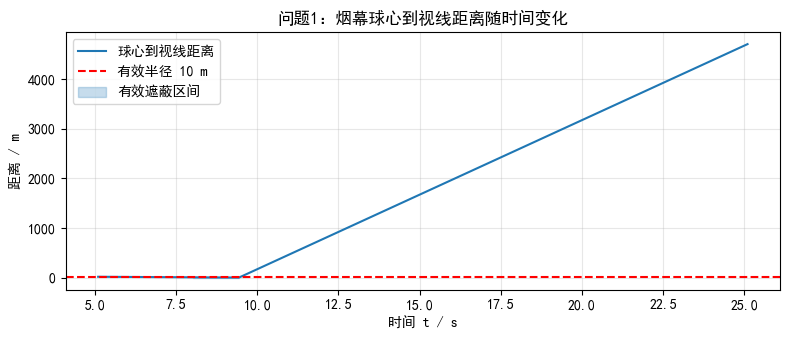

In [2]:
v1, td1, tf1 = 120.0, 1.5, 3.6
h1 = heading_to_fake(FY1)
th1 = float(np.arctan2(h1[1], h1[0]))
b1 = make_bomb(FY1, th1, v1, td1, tf1)
J1 = union_duration([b1], M1, dt=0.01)
pd1, pe1 = b1["drop"], b1["det"]

print("========== 问题 1 ==========")
print("飞行速度: {:.1f} m/s".format(v1))
print("航向:", h1)
print("投放时刻: {:.1f} s, 起爆时刻: {:.1f} s".format(td1, td1 + tf1))
print("投放点: ({:.3f}, {:.3f}, {:.3f})".format(*pd1))
print("起爆点: ({:.3f}, {:.3f}, {:.3f})".format(*pe1))
print("有效遮蔽时长 J1 = {:.2f} s".format(J1))

ts, dists, mask, _ = shielding_series([b1], M1, dt=0.01)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ts, dists, label="球心到视线距离")
ax.axhline(R_SMOKE, color="r", ls="--", label="有效半径 10 m")
ax.fill_between(ts, 0, R_SMOKE, where=mask, color="C0", alpha=0.25, label="有效遮蔽区间")
ax.set_xlabel("时间 t / s"); ax.set_ylabel("距离 / m")
ax.set_title("问题1：烟幕球心到视线距离随时间变化")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR / "问题1_遮蔽距离随时间变化.png", dpi=180, bbox_inches="tight")
fig.savefig(FIG_DIR / "q1_distance_time.png", dpi=180, bbox_inches="tight")
plt.show()


## 4. 问题 2：FY1 单弹优化

开始优化问题 2 …



========== 问题 2 ==========
速度: 75.99 m/s, 航向角: 3.101964 rad
航向单位向量: [-0.9992  0.0396  0.    ]
投放: 0.109 s, 引信: 2.540 s, 起爆: 2.648 s
投放点: (17791.753, 0.327, 1800.000)
起爆点: (17598.898, 7.974, 1768.390)
有效遮蔽时长 J2 = 4.70 s (相对问题1 +3.27 s)


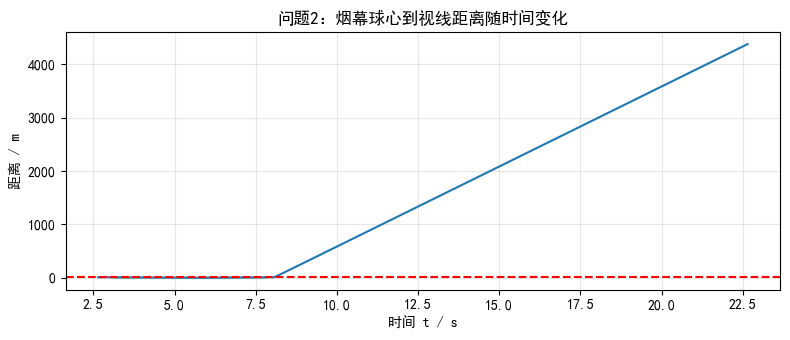

In [3]:
print("开始优化问题 2 …")
cands_q2 = optimize_single_uav("FY1", "M1", n_keep=6, te_range=(1.0, 25.0))
best2 = cands_q2[0]
theta2, v2, td2, tf2 = best2["theta"], best2["speed"], best2["t_drop"], best2["t_fuse"]
h2 = best2["heading"]
pd2, pe2 = best2["drop"], best2["det"]
J2 = best2["J"]

print("\n========== 问题 2 ==========")
print("速度: {:.2f} m/s, 航向角: {:.6f} rad".format(v2, theta2))
print("航向单位向量:", h2)
print("投放: {:.3f} s, 引信: {:.3f} s, 起爆: {:.3f} s".format(td2, tf2, td2 + tf2))
print("投放点: ({:.3f}, {:.3f}, {:.3f})".format(*pd2))
print("起爆点: ({:.3f}, {:.3f}, {:.3f})".format(*pe2))
print("有效遮蔽时长 J2 = {:.2f} s (相对问题1 +{:.2f} s)".format(J2, J2 - J1))

ts2, d2, m2, _ = shielding_series([best2], M1, dt=0.01)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ts2, d2); ax.axhline(R_SMOKE, color="r", ls="--")
ax.fill_between(ts2, 0, R_SMOKE, where=m2, color="C2", alpha=0.28)
ax.set_xlabel("时间 t / s"); ax.set_ylabel("距离 / m")
ax.set_title("问题2：烟幕球心到视线距离随时间变化")
ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(IMG_DIR / "问题2_遮蔽距离随时间变化.png", dpi=180, bbox_inches="tight")
fig.savefig(FIG_DIR / "q2_distance_time.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. 问题 3：FY1 投放 3 枚烟幕干扰弹干扰 M1

同一架无人机航向、速度固定；三枚弹投放时刻满足间隔 $\ge 1\,\mathrm{s}$。目标为三枚弹遮蔽时间的**并集**最大化。
采用“视线落点候选 + 同航线时序组合搜索”。


开始优化问题 3 …


========== 问题 3 ==========
速度: 106.51 m/s, 航向角: 3.129641 rad
弹1: td=0.000, tf=3.161, te=3.161, det=(17463.39, 4.02, 1751.05)
弹2: td=1.714, tf=3.598, te=5.313, det=(17234.22, 6.76, 1736.56)
弹3: td=2.714, tf=3.598, te=6.313, det=(17127.73, 8.04, 1736.56)
并集有效遮蔽时长 J3 = 5.16 s


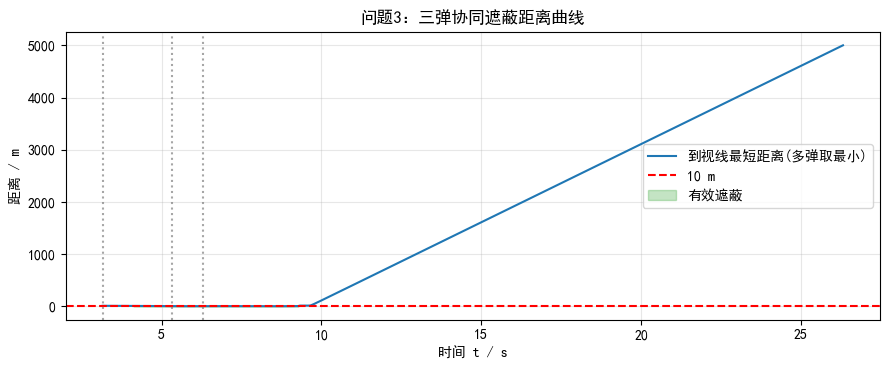

In [4]:
def optimize_q3():
    uav0, p_m = UAVS["FY1"], MISSILES["M1"]
    singles = optimize_single_uav("FY1", "M1", n_keep=12, te_range=(1.0, 35.0))
    best = {"J": 0.0, "theta": None, "speed": None, "bombs": None}

    # 构造基线：最优单弹航迹上错开投放三枚
    if singles:
        s0 = singles[0]
        theta, speed = s0["theta"], s0["speed"]
        for g12 in np.linspace(1.0, 5.0, 9):
            for g23 in np.linspace(1.0, 6.0, 9):
                for tf2 in np.linspace(0.5, fuse_max(uav0), 8):
                    for tf3 in np.linspace(0.5, fuse_max(uav0), 8):
                        drops = [s0["t_drop"], s0["t_drop"] + g12, s0["t_drop"] + g12 + g23]
                        bombs = [
                            make_bomb(uav0, theta, speed, drops[0], s0["t_fuse"], 1),
                            make_bomb(uav0, theta, speed, drops[1], tf2, 2),
                            make_bomb(uav0, theta, speed, drops[2], tf3, 3),
                        ]
                        if any(b["det"][2] <= 1 for b in bombs):
                            continue
                        tes = sorted(b["t_det"] for b in bombs)
                        if tes[1] - tes[0] < 0.8 or tes[2] - tes[1] < 0.8:
                            continue
                        J = union_duration(bombs, p_m, dt=0.04)
                        if J > best["J"]:
                            best = {"J": J, "theta": theta, "speed": speed, "bombs": bombs}

    for seed in singles[:6]:
        theta, speed = seed["theta"], seed["speed"]
        for td1 in np.linspace(max(0.0, seed["t_drop"] - 2), seed["t_drop"] + 2, 7):
            for g12 in np.linspace(1.0, 6.0, 8):
                for g23 in np.linspace(1.0, 8.0, 8):
                    drops = [td1, td1 + g12, td1 + g12 + g23]
                    tf_hi = fuse_max(uav0)
                    for tf1 in np.linspace(max(0.4, seed["t_fuse"] - 1.5), min(tf_hi, seed["t_fuse"] + 1.5), 6):
                        for tf2 in np.linspace(0.5, tf_hi, 7):
                            for tf3 in np.linspace(0.5, tf_hi, 7):
                                bombs = [
                                    make_bomb(uav0, theta, speed, drops[0], tf1, 1),
                                    make_bomb(uav0, theta, speed, drops[1], tf2, 2),
                                    make_bomb(uav0, theta, speed, drops[2], tf3, 3),
                                ]
                                if any(b["det"][2] <= 1 for b in bombs):
                                    continue
                                tes = sorted(b["t_det"] for b in bombs)
                                if tes[1] - tes[0] < 0.8 or tes[2] - tes[1] < 0.8:
                                    continue
                                J = union_duration(bombs, p_m, dt=0.05)
                                if J > best["J"]:
                                    best = {"J": J, "theta": theta, "speed": speed, "bombs": bombs}

    if len(singles) >= 3:
        for i in range(len(singles)):
            for j in range(i + 1, len(singles)):
                for k in range(j + 1, len(singles)):
                    trio = sorted([singles[i], singles[j], singles[k]], key=lambda b: b["t_drop"])
                    if trio[1]["t_drop"] - trio[0]["t_drop"] < 1 or trio[2]["t_drop"] - trio[1]["t_drop"] < 1:
                        continue
                    theta = trio[0]["theta"]
                    speed = float(np.clip(np.mean([b["speed"] for b in trio]), 70, 140))
                    bombs = [
                        make_bomb(uav0, theta, speed, trio[0]["t_drop"], trio[0]["t_fuse"], 1),
                        make_bomb(uav0, theta, speed, trio[1]["t_drop"], trio[1]["t_fuse"], 2),
                        make_bomb(uav0, theta, speed, trio[2]["t_drop"], trio[2]["t_fuse"], 3),
                    ]
                    if any(b["det"][2] <= 1 for b in bombs):
                        continue
                    J = union_duration(bombs, p_m, dt=0.04)
                    if J > best["J"]:
                        best = {"J": J, "theta": theta, "speed": speed, "bombs": bombs}

    theta, speed, bombs0 = best["theta"], best["speed"], best["bombs"]
    for dth in np.linspace(-0.05, 0.05, 5):
        for dv in np.linspace(-10, 10, 5):
            bombs = []
            ok = True
            for idx, b0 in enumerate(bombs0, 1):
                b = make_bomb(
                    uav0, theta + dth, float(np.clip(speed + dv, 70, 140)),
                    b0["t_drop"], b0["t_fuse"], idx,
                )
                if b["det"][2] <= 1:
                    ok = False
                    break
                bombs.append(b)
            if not ok:
                continue
            if bombs[1]["t_drop"] - bombs[0]["t_drop"] < 1 or bombs[2]["t_drop"] - bombs[1]["t_drop"] < 1:
                continue
            J = union_duration(bombs, p_m, dt=0.03)
            if J > best["J"]:
                best = {
                    "J": J,
                    "theta": theta + dth,
                    "speed": float(np.clip(speed + dv, 70, 140)),
                    "bombs": bombs,
                }

    best["J"] = union_duration(best["bombs"], p_m, dt=0.01)
    return best


print("开始优化问题 3 …")
q3 = optimize_q3()
J3 = q3["J"]
print("========== 问题 3 ==========")
print("速度: {:.2f} m/s, 航向角: {:.6f} rad".format(q3["speed"], q3["theta"]))
for b in q3["bombs"]:
    print(
        "弹{}: td={:.3f}, tf={:.3f}, te={:.3f}, det=({})".format(
            b["id"], b["t_drop"], b["t_fuse"], b["t_det"],
            ", ".join("{:.2f}".format(x) for x in b["det"]),
        )
    )
print("并集有效遮蔽时长 J3 = {:.2f} s".format(J3))

ts3, d3, m3, _ = shielding_series(q3["bombs"], M1, dt=0.01)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(ts3, d3, label="到视线最短距离(多弹取最小)")
ax.axhline(R_SMOKE, color="r", ls="--", label="10 m")
ax.fill_between(ts3, 0, R_SMOKE, where=m3, color="C2", alpha=0.28, label="有效遮蔽")
for b in q3["bombs"]:
    ax.axvline(b["t_det"], color="gray", ls=":", alpha=0.7)
ax.set_xlabel("时间 t / s"); ax.set_ylabel("距离 / m")
ax.set_title("问题3：三弹协同遮蔽距离曲线")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(IMG_DIR / "问题3_遮蔽距离随时间变化.png", dpi=180, bbox_inches="tight")
fig.savefig(FIG_DIR / "q3_distance_time.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. 问题 4：FY1/FY2/FY3 各投 1 枚干扰 M1

三机独立航向速度；目标为三枚弹遮蔽时间并集最大化。策略：各机先做视线落点优化，再按起爆时序互补做联合微调。


开始优化问题 4 …
  优化 FY1 …


  优化 FY2 …


  优化 FY3 …


========== 问题 4 ==========
FY1: v=80.92, theta=0.1051, td=0.560, te=1.217, Ji=4.79
FY2: v=135.97, theta=-1.5228, td=3.804, te=9.932, Ji=5.00
FY3: v=140.00, theta=2.6154, td=33.905, te=45.186, Ji=6.03
并集有效遮蔽时长 J4 = 15.82 s


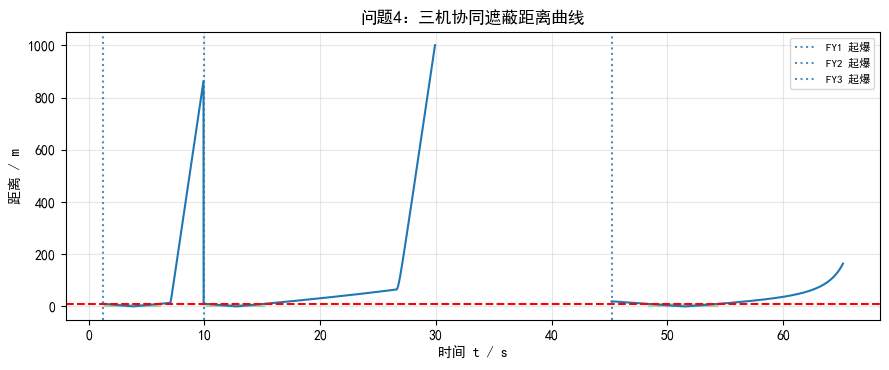

In [5]:
def optimize_q4():
    p_m = MISSILES["M1"]
    windows = [(1.0, 12.0), (8.0, 25.0), (18.0, 45.0)]
    names = ["FY1", "FY2", "FY3"]
    singles = []
    for name, wr in zip(names, windows):
        print("  优化", name, "…")
        cands = optimize_single_uav(name, "M1", n_keep=5, te_range=wr)
        if not cands or cands[0]["J"] < 0.1:
            cands = optimize_single_uav(name, "M1", n_keep=5, te_range=(1.0, 55.0))
        singles.append(cands[0] if cands else None)

    for i, name in enumerate(names):
        if singles[i] is None or singles[i]["J"] < 0.05:
            print("  重试", name)
            cands = optimize_single_uav(name, "M1", n_keep=8)
            singles[i] = cands[0]

    bombs = [dict(s) for s in singles]
    for b in bombs:
        b["id"] = 1
    best_J = union_duration(bombs, p_m, dt=0.01)
    params = np.array([[b["theta"], b["speed"], b["t_drop"], b["t_fuse"]] for b in bombs])

    rng = np.random.default_rng(2025)
    for _ in range(2500):
        trial = params.copy()
        k = int(rng.integers(0, 3))
        trial[k, 0] += rng.normal(0, 0.05)
        trial[k, 1] = float(np.clip(trial[k, 1] + rng.normal(0, 5), 70, 140))
        trial[k, 2] = max(0.0, trial[k, 2] + rng.normal(0, 1.0))
        trial[k, 3] = float(
            np.clip(trial[k, 3] + rng.normal(0, 0.8), 0.25, fuse_max(UAVS[names[k]]))
        )
        new_bombs = []
        ok = True
        for i, name in enumerate(names):
            b = make_bomb(UAVS[name], trial[i, 0], trial[i, 1], trial[i, 2], trial[i, 3], 1)
            if b["det"][2] <= 1:
                ok = False
                break
            new_bombs.append(b)
        if not ok:
            continue
        J = union_duration(new_bombs, p_m, dt=0.04)
        if J > best_J:
            best_J = union_duration(new_bombs, p_m, dt=0.01)
            params = trial
            bombs = new_bombs

    strategies = []
    for i, name in enumerate(names):
        b = bombs[i]
        strategies.append({
            "uav": name,
            "theta": b["theta"],
            "speed": b["speed"],
            "bomb": b,
            "Ji": union_duration([b], p_m, dt=0.01),
        })
    return {"strategies": strategies, "bombs": bombs, "J": best_J}


print("开始优化问题 4 …")
q4 = optimize_q4()
J4 = q4["J"]
print("========== 问题 4 ==========")
for s in q4["strategies"]:
    b = s["bomb"]
    print(
        "{}: v={:.2f}, theta={:.4f}, td={:.3f}, te={:.3f}, Ji={:.2f}".format(
            s["uav"], s["speed"], s["theta"], b["t_drop"], b["t_det"], s["Ji"]
        )
    )
print("并集有效遮蔽时长 J4 = {:.2f} s".format(J4))

ts4, d4, m4, _ = shielding_series(q4["bombs"], M1, dt=0.01)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(ts4, d4); ax.axhline(R_SMOKE, color="r", ls="--")
ax.fill_between(ts4, 0, R_SMOKE, where=m4, color="C2", alpha=0.28)
for s in q4["strategies"]:
    ax.axvline(s["bomb"]["t_det"], ls=":", alpha=0.8, label=s["uav"] + " 起爆")
ax.set_xlabel("时间 t / s"); ax.set_ylabel("距离 / m")
ax.set_title("问题4：三机协同遮蔽距离曲线")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(IMG_DIR / "问题4_遮蔽距离随时间变化.png", dpi=180, bbox_inches="tight")
fig.savefig(FIG_DIR / "q4_distance_time.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. 问题 5：五机对三导弹分层协同

分层策略：
1. **任务分配**：按几何邻近将无人机指派给导弹（每枚导弹至少一架）；
2. **单机多弹优化**：对指派任务做视线落点 + 时序组合；
3. 目标为各导弹遮蔽时长之和最大化。


开始优化问题 5 …
  FY1 -> M1, n=2 …


  FY4 -> M1, n=2 …


  FY2 -> M2, n=3 …


  FY3 -> M3, n=2 …


  FY5 -> M3, n=2 …


========== 问题 5 ==========
M1 有效遮蔽时长 = 10.00 s（弹数 4）
M2 有效遮蔽时长 = 4.76 s（弹数 3）
M3 有效遮蔽时长 = 5.24 s（弹数 4）
三导弹合计 J5 = 20.00 s


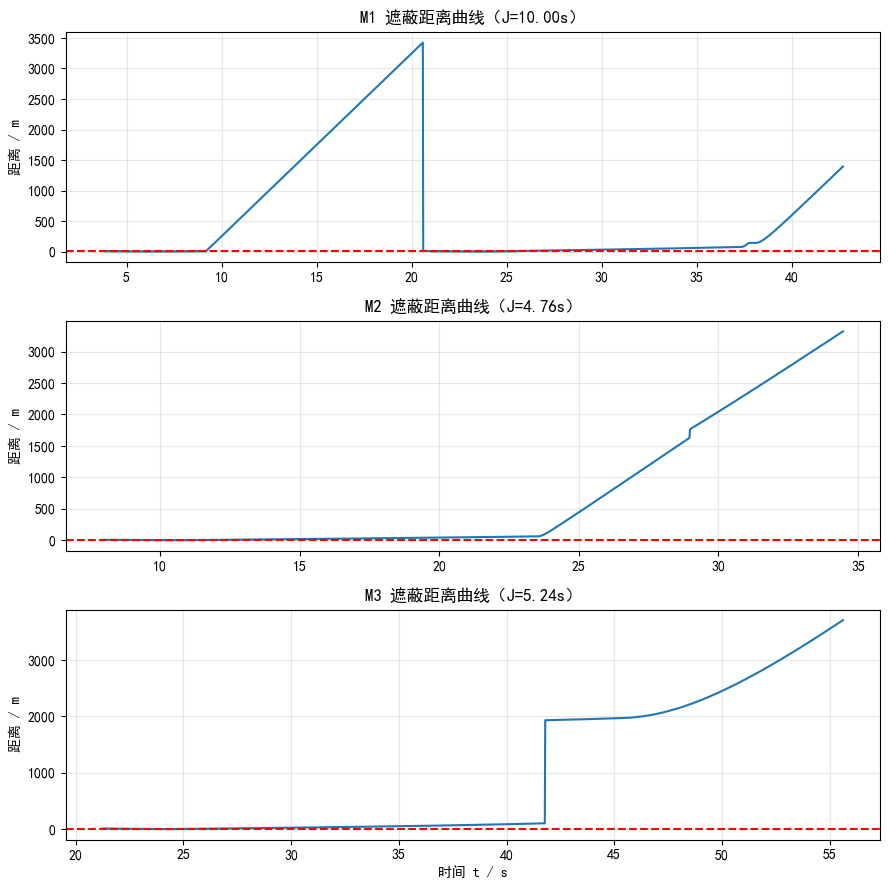

In [6]:
def optimize_multi_on_uav(uav_name, missile_name, n_bombs):
    uav0, p_m = UAVS[uav_name], MISSILES[missile_name]
    singles = optimize_single_uav(uav_name, missile_name, n_keep=10)
    if not singles:
        return {"uav": uav_name, "missile": missile_name, "bombs": [], "J": 0.0}

    best = {"J": 0.0, "bombs": None, "theta": None, "speed": None}
    pool = singles[:8]
    for comb in combinations(range(len(pool)), min(n_bombs, len(pool))):
        chosen = sorted([pool[i] for i in comb], key=lambda b: b["t_drop"])
        ok_gap = all(
            chosen[i + 1]["t_drop"] - chosen[i]["t_drop"] >= 1.0
            for i in range(len(chosen) - 1)
        )
        if not ok_gap:
            continue
        theta = chosen[0]["theta"]
        speed = float(np.clip(np.mean([b["speed"] for b in chosen]), 70, 140))
        bombs = [
            make_bomb(uav0, theta, speed, b["t_drop"], b["t_fuse"], i + 1)
            for i, b in enumerate(chosen)
        ]
        if any(b["det"][2] <= 1 for b in bombs):
            continue
        J = union_duration(bombs, p_m, dt=0.05)
        if J > best["J"]:
            best = {"J": J, "bombs": bombs, "theta": theta, "speed": speed}

    if best["bombs"] is None:
        b0 = singles[0]
        bombs = []
        td = b0["t_drop"]
        for i in range(n_bombs):
            bombs.append(make_bomb(uav0, b0["theta"], b0["speed"], td, b0["t_fuse"], i + 1))
            td += max(DROP_GAP, 2.5)
        best = {
            "J": union_duration(bombs, p_m, dt=0.01),
            "bombs": bombs,
            "theta": b0["theta"],
            "speed": b0["speed"],
        }

    theta, speed, bombs0 = best["theta"], best["speed"], best["bombs"]
    for dth in np.linspace(-0.05, 0.05, 5):
        for dv in [-8, 0, 8]:
            bombs = [
                make_bomb(
                    uav0, theta + dth, float(np.clip(speed + dv, 70, 140)),
                    b["t_drop"], b["t_fuse"], i + 1,
                )
                for i, b in enumerate(bombs0)
            ]
            if any(b["det"][2] <= 1 for b in bombs):
                continue
            if any(bombs[i + 1]["t_drop"] - bombs[i]["t_drop"] < 1 for i in range(len(bombs) - 1)):
                continue
            J = union_duration(bombs, p_m, dt=0.03)
            if J > best["J"]:
                best = {
                    "J": J,
                    "bombs": bombs,
                    "theta": theta + dth,
                    "speed": float(np.clip(speed + dv, 70, 140)),
                }
    best["J"] = union_duration(best["bombs"], p_m, dt=0.01)
    best["uav"] = uav_name
    best["missile"] = missile_name
    return best


def optimize_q5():
    # FY1/FY4 靠近 M1 来向；FY2 偏北配合 M2；FY3/FY5 偏南配合 M3
    assign = {"FY1": "M1", "FY4": "M1", "FY2": "M2", "FY3": "M3", "FY5": "M3"}
    n_map = {"FY1": 2, "FY4": 2, "FY2": 3, "FY3": 2, "FY5": 2}
    strategies = []
    by_m = {"M1": [], "M2": [], "M3": []}
    for uav, missile in assign.items():
        print("  {} -> {}, n={} …".format(uav, missile, n_map[uav]))
        s = optimize_multi_on_uav(uav, missile, n_map[uav])
        strategies.append(s)
        by_m[missile].extend(s["bombs"])
    durations = {m: union_duration(bs, MISSILES[m], dt=0.01) for m, bs in by_m.items()}
    return {
        "assign": assign,
        "n_map": n_map,
        "strategies": strategies,
        "by_missile": by_m,
        "durations": durations,
        "total": float(sum(durations.values())),
    }


print("开始优化问题 5 …")
q5 = optimize_q5()
print("========== 问题 5 ==========")
for m, J in q5["durations"].items():
    print("{} 有效遮蔽时长 = {:.2f} s（弹数 {}）".format(m, J, len(q5["by_missile"][m])))
print("三导弹合计 J5 = {:.2f} s".format(q5["total"]))

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=False)
for ax, m in zip(axes, ["M1", "M2", "M3"]):
    ts, d, mask, J = shielding_series(q5["by_missile"][m], MISSILES[m], dt=0.02)
    if len(ts):
        ax.plot(ts, d)
        ax.axhline(R_SMOKE, color="r", ls="--")
        ax.fill_between(ts, 0, R_SMOKE, where=mask, color="C2", alpha=0.28)
    ax.set_title("{} 遮蔽距离曲线（J={:.2f}s）".format(m, J))
    ax.set_ylabel("距离 / m")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("时间 t / s")
plt.tight_layout()
fig.savefig(IMG_DIR / "问题5_三导弹遮蔽距离曲线.png", dpi=180, bbox_inches="tight")
fig.savefig(FIG_DIR / "q5_distance_time.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. 导出 result1/2/3.xlsx 与汇总图表

已保存 result1.xlsx / result2.xlsx / result3.xlsx
   无人机运动方向  无人机运动速度 (m/s)  烟幕干扰弹编号  烟幕干扰弹投放点的x坐标 (m)  烟幕干扰弹投放点的y坐标 (m)  \
0  179.315        106.505        1         17800.000             0.000   
1  179.315        106.505        2         17617.433             2.182   
2  179.315        106.505        3         17510.935             3.455   

   烟幕干扰弹投放点的z坐标 (m)  烟幕干扰弹起爆点的x坐标 (m)  烟幕干扰弹起爆点的y坐标 (m)  烟幕干扰弹起爆点的z坐标 (m)  \
0            1800.0         17463.391             4.023          1751.048   
1            1800.0         17234.224             6.762          1736.557   
2            1800.0         17127.727             8.035          1736.557   

   有效干扰时长 (s)  
0        5.16  
1        5.16  
2        5.16  
  无人机编号  无人机运动方向  无人机运动速度 (m/s)  烟幕干扰弹编号  烟幕干扰弹投放点的x坐标 (m)  烟幕干扰弹投放点的y坐标 (m)  \
0   FY1    6.023         80.919        1         17845.052             4.754   
1   FY2  -87.253        135.972        1         12024.789           883.399   
2   FY3  149.852        140.000        1   

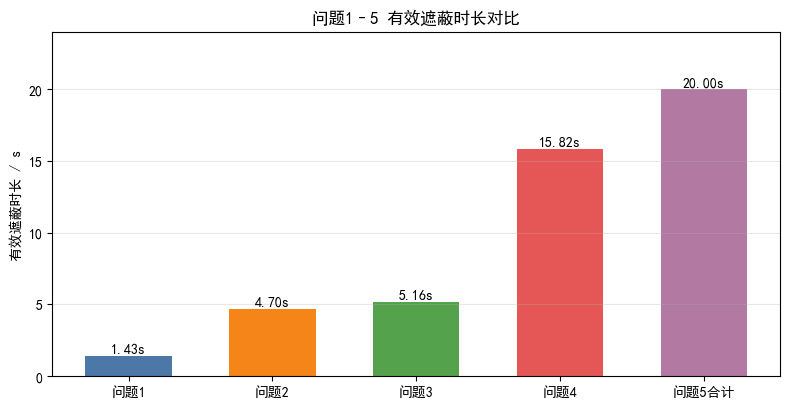

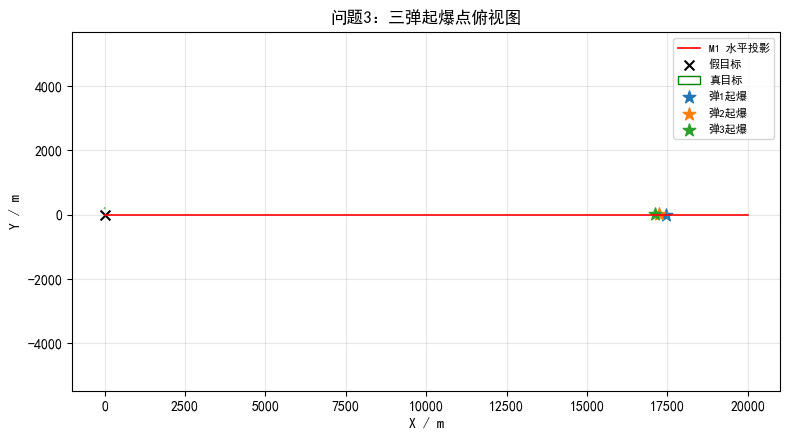

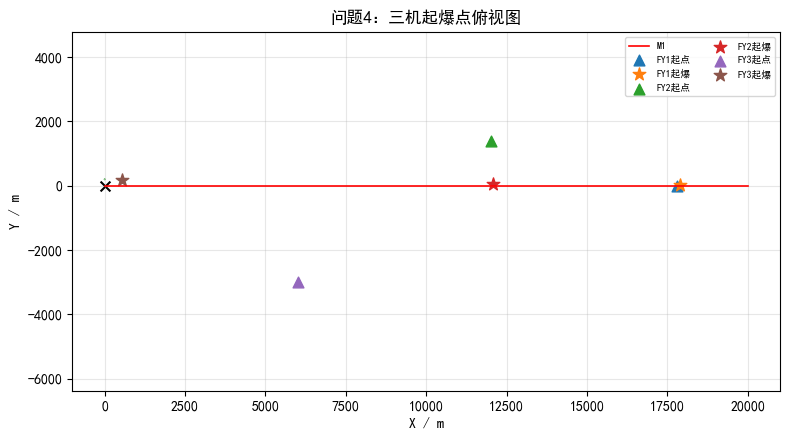

    问题              场景  有效遮蔽时长(s)
   问题1 FY1×1 vs M1(给定)       1.43
   问题2 FY1×1 vs M1(优化)       4.70
   问题3     FY1×3 vs M1       5.16
   问题4 FY1/2/3×1 vs M1      15.82
问题5-M1      分配机群 vs M1      10.00
问题5-M2      分配机群 vs M2       4.76
问题5-M3      分配机群 vs M3       5.24
 问题5合计       五机 vs 三导弹      20.00
完成。图片目录: C:\Users\luyus\数学建模\作业\南京工业大学暑假集训\作业一\图片


In [7]:
def ang_deg(heading):
    return float(np.degrees(np.arctan2(heading[1], heading[0])))


def rows_from_bombs(uav, bombs, duration, missile=None):
    rows = []
    for b in bombs:
        row = {
            "无人机编号": uav,
            "无人机运动方向": round(ang_deg(b["heading"]), 3),
            "无人机运动速度 (m/s)": round(b["speed"], 3),
            "烟幕干扰弹编号": b["id"],
            "烟幕干扰弹投放点的x坐标 (m)": round(float(b["drop"][0]), 3),
            "烟幕干扰弹投放点的y坐标 (m)": round(float(b["drop"][1]), 3),
            "烟幕干扰弹投放点的z坐标 (m)": round(float(b["drop"][2]), 3),
            "烟幕干扰弹起爆点的x坐标 (m)": round(float(b["det"][0]), 3),
            "烟幕干扰弹起爆点的y坐标 (m)": round(float(b["det"][1]), 3),
            "烟幕干扰弹起爆点的z坐标 (m)": round(float(b["det"][2]), 3),
            "有效干扰时长 (s)": round(float(duration), 3),
        }
        if missile is not None:
            row["干扰的导弹编号"] = missile
        rows.append(row)
    return rows


df1 = pd.DataFrame(rows_from_bombs("FY1", q3["bombs"], J3))
df1 = df1.drop(columns=["无人机编号"])
df1.to_excel("result1.xlsx", index=False)
df1.to_excel(TAB_DIR / "问题3_result1.xlsx", index=False)

rows2 = []
for s in q4["strategies"]:
    rows2 += rows_from_bombs(s["uav"], [s["bomb"]], J4)
df2 = pd.DataFrame(rows2)
df2.to_excel("result2.xlsx", index=False)
df2.to_excel(TAB_DIR / "问题4_result2.xlsx", index=False)

rows3 = []
for s in q5["strategies"]:
    rows3 += rows_from_bombs(
        s["uav"], s["bombs"], q5["durations"][s["missile"]], s["missile"]
    )
df3 = pd.DataFrame(rows3)
df3.to_excel("result3.xlsx", index=False)
df3.to_excel(TAB_DIR / "问题5_result3.xlsx", index=False)

print("已保存 result1.xlsx / result2.xlsx / result3.xlsx")
print(df1)
print(df2)
print(df3)

fig, ax = plt.subplots(figsize=(8, 4.2))
names = ["问题1", "问题2", "问题3", "问题4", "问题5合计"]
vals = [J1, J2, J3, J4, q5["total"]]
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2"]
bars = ax.bar(names, vals, color=colors, width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.08, "{:.2f}s".format(v), ha="center", va="bottom")
ax.set_ylabel("有效遮蔽时长 / s")
ax.set_title("问题1–5 有效遮蔽时长对比")
ax.set_ylim(0, max(vals) * 1.2)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR / "问题1至5_遮蔽时长对比图.png", dpi=180, bbox_inches="tight")
fig.savefig(FIG_DIR / "q1_to_q5_duration_compare.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
t_mis = np.linspace(0, missile_hit_time(M1), 100)
mis = missile_pos(t_mis, M1)
ax.plot(mis[:, 0], mis[:, 1], "r-", lw=1.2, label="M1 水平投影")
ax.scatter(0, 0, c="k", marker="x", s=50, label="假目标")
ax.add_patch(plt.Circle((0, 200), 7, fill=False, color="g", label="真目标"))
for b in q3["bombs"]:
    ax.scatter(b["det"][0], b["det"][1], marker="*", s=90, label="弹{}起爆".format(b["id"]))
    ax.add_patch(plt.Circle((b["det"][0], b["det"][1]), 10, alpha=0.12))
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("X / m"); ax.set_ylabel("Y / m")
ax.set_title("问题3：三弹起爆点俯视图")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR / "问题3_起爆点俯视图.png", dpi=180, bbox_inches="tight")
fig.savefig(FIG_DIR / "q3_topview.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(mis[:, 0], mis[:, 1], "r-", lw=1.2, label="M1")
ax.scatter(0, 0, c="k", marker="x", s=50)
ax.add_patch(plt.Circle((0, 200), 7, fill=False, color="g"))
for s in q4["strategies"]:
    b = s["bomb"]
    ax.scatter(UAVS[s["uav"]][0], UAVS[s["uav"]][1], marker="^", s=60, label=s["uav"] + "起点")
    ax.scatter(b["det"][0], b["det"][1], marker="*", s=90, label=s["uav"] + "起爆")
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("X / m"); ax.set_ylabel("Y / m")
ax.set_title("问题4：三机起爆点俯视图")
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR / "问题4_起爆点俯视图.png", dpi=180, bbox_inches="tight")
fig.savefig(FIG_DIR / "q4_topview.png", dpi=180, bbox_inches="tight")
plt.show()

summary = pd.DataFrame([
    {"问题": "问题1", "场景": "FY1×1 vs M1(给定)", "有效遮蔽时长(s)": round(J1, 2)},
    {"问题": "问题2", "场景": "FY1×1 vs M1(优化)", "有效遮蔽时长(s)": round(J2, 2)},
    {"问题": "问题3", "场景": "FY1×3 vs M1", "有效遮蔽时长(s)": round(J3, 2)},
    {"问题": "问题4", "场景": "FY1/2/3×1 vs M1", "有效遮蔽时长(s)": round(J4, 2)},
    {"问题": "问题5-M1", "场景": "分配机群 vs M1", "有效遮蔽时长(s)": round(q5["durations"]["M1"], 2)},
    {"问题": "问题5-M2", "场景": "分配机群 vs M2", "有效遮蔽时长(s)": round(q5["durations"]["M2"], 2)},
    {"问题": "问题5-M3", "场景": "分配机群 vs M3", "有效遮蔽时长(s)": round(q5["durations"]["M3"], 2)},
    {"问题": "问题5合计", "场景": "五机 vs 三导弹", "有效遮蔽时长(s)": round(q5["total"], 2)},
])
summary.to_excel(TAB_DIR / "问题1至5_结果汇总表.xlsx", index=False)
print(summary.to_string(index=False))
print("完成。图片目录:", IMG_DIR.resolve())


## 9. 结果小结

依次运行全部单元格后，将得到：

- `result1.xlsx` / `result2.xlsx` / `result3.xlsx`
- `图片/` 与 `figures/` 中的对比图、距离曲线与俯视图
- `表格/问题1至5_结果汇总表.xlsx`
